In [14]:
import pickle
import numpy as np
from scipy.special import softmax
import matplotlib.pyplot as plt
hw5p1 = pickle.load(open('hw5p1.pkl', 'rb'))

Problem - 1

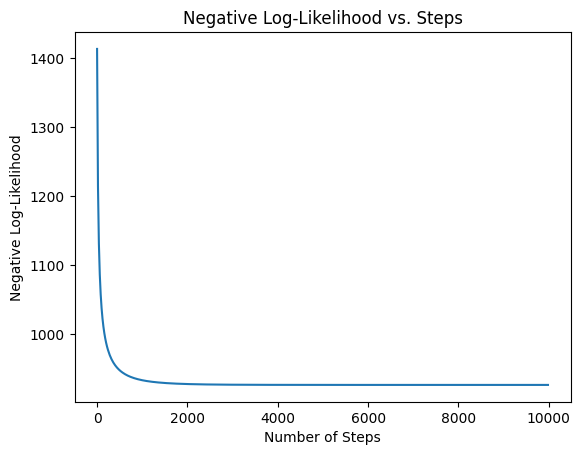

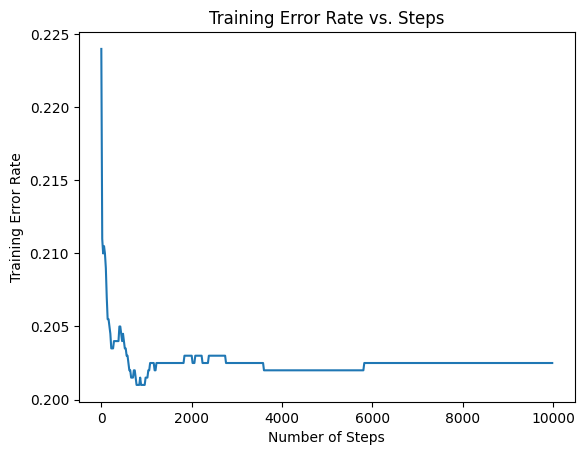

Training Error Rate: 0.2025
Test Error Rate: 0.2092
end


In [46]:
#Problem 1
def logreg_nll_gd(K, eta, T, features, labels):
    n, d = features.shape
    W = np.zeros((d, K))

    # Lists to store values for plotting
    neg_log_likelihoods = []
    training_errors = []
    
    for t in range(1, T+1):
        # Compute probabilities(softmax) for each class
        #features is an matrix of row feature vectors and W is a matrix of column weight vectors
        #so this function return an array of all the products of these matrix elements
        probabilities = softmax(np.dot(features, W), axis=1)

        # Compute the negative log-likelihood
        neg_log_likelihood = -np.sum(np.log(probabilities[np.arange(n), labels]))
        neg_log_likelihoods.append(neg_log_likelihood)

        # Compute the training error rate
        predictions = np.argmax(probabilities, axis=1)
        training_error_rate = np.mean(predictions != labels)
        training_errors.append(training_error_rate)

        # Compute gradients
        indicator_matrix = np.eye(K)[labels]
        gradients = np.dot(features.T, probabilities - indicator_matrix)

        # Update parameter matrix W using gradient descent
        W -= (eta) * gradients
    
    # Plot negative log-likelihood
    plt.figure()
    plt.plot(np.arange(1, T+1, 20), neg_log_likelihoods[19::20])
    plt.xlabel('Number of Steps')
    plt.ylabel('Negative Log-Likelihood')
    plt.title('Negative Log-Likelihood vs. Steps')
    plt.show()

    # Plot training error rate
    plt.figure()
    plt.plot(np.arange(1, T+1, 20), training_errors[19::20])
    plt.xlabel('Number of Steps')
    plt.ylabel('Training Error Rate')
    plt.title('Training Error Rate vs. Steps')
    plt.show()
    
    return W

# Load data
import pickle
hw5p1 = pickle.load(open('hw5p1.pkl', 'rb'))
features = hw5p1['data']
labels = hw5p1['labels']

# Set parameters
K = 3
eta = 2 / len(features)
T = 10000

# Run gradient descent
parameter_matrix = logreg_nll_gd(K, eta, T, features, labels)

# Evaluate the final classifier

probabilities_train = softmax(np.dot(hw5p1['data'], parameter_matrix), axis=1)
predictions_train = np.argmax(probabilities_train, axis=1)
train_error_rate = np.mean(predictions_train != hw5p1['labels'])

probabilities_test = softmax(np.dot(hw5p1['testdata'], parameter_matrix), axis=1)
predictions_test = np.argmax(probabilities_test, axis=1)
test_error_rate = np.mean(predictions_test != hw5p1['testlabels'])


# Print results
print(f"Training Error Rate: {train_error_rate:.4f}")
print(f"Test Error Rate: {test_error_rate:.4f}")
print("end")


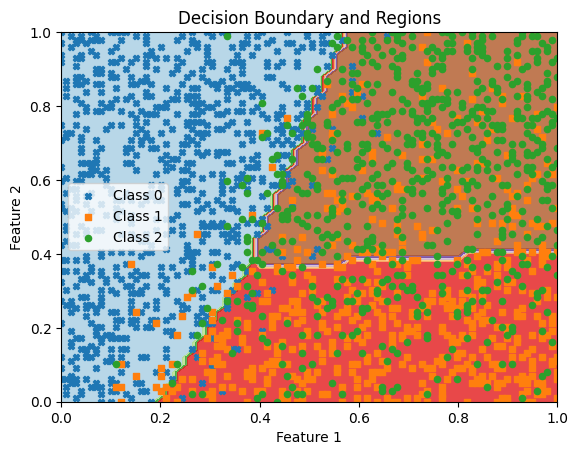

In [16]:
#Problem 1 decision boundaries(just to check)
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

def plot_decision_boundary(features, labels, parameter_matrix):
    # Generate a mesh grid
    h = 0.02  # Step size in the mesh
    x_min, x_max = features[:, 0].min() - 1, features[:, 0].max() + 1
    y_min, y_max = features[:, 1].min() - 1, features[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Flatten the mesh grid and append an "always-1" feature
    mesh_data = np.c_[xx.ravel(), yy.ravel(), np.ones_like(xx.ravel())]

    # Predict class probabilities for each point in the mesh
    probabilities = softmax(np.dot(mesh_data, parameter_matrix), axis=1)
    
    # Reshape predictions to the shape of the mesh grid
    predictions = np.argmax(probabilities, axis=1).reshape(xx.shape)

    # Plot decision boundaries and regions
    plt.contourf(xx, yy, predictions, cmap=plt.cm.Paired, alpha=0.8)

    # Scatter plot for training data with different shapes for different classes
    markers = ['X', 's', 'o']
    
    for i in range(3):
        plt.scatter(features[labels == i, 0], features[labels == i, 1], marker=markers[i], label=f'Class {i}',s=20)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary and Regions')
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.legend()
    plt.show()

plot_decision_boundary(features[:, :2], labels, parameter_matrix)


Problem - 5

In [23]:
#Problem 5
import torch
import pickle

def logreg_nll_gd_ad(K, eta, T, X, y):
    X = torch.tensor(X, dtype=torch.double)
    y = torch.tensor(y, dtype=torch.long)  # Ensure the dtype is long for indexing
    W = torch.zeros(X.shape[1], K, dtype=torch.double, requires_grad=True)

    for _ in range(T):
        J = torch.sum(torch.log(torch.sum(torch.exp(torch.matmul(X, W)), dim=1)) - torch.matmul(X, W)[torch.arange(X.shape[0]), y])
        J.backward()
        
        with torch.no_grad():
            W -= eta * W.grad
            W.grad.zero_()

    return W.detach()

# Load data
hw5p1 = pickle.load(open('hw5p1.pkl', 'rb'))
features = hw5p1['data']
labels = hw5p1['labels']

# Set parameters
K = 3
eta = 2 / len(features)
T = 10000

# Run gradient descent with autograd
parameter_matrix_ad = logreg_nll_gd_ad(K, eta, T, features, labels)

# Print Frobenius norm difference
frobenius_norm_diff = torch.norm(parameter_matrix_ad - parameter_matrix, p='fro').item()
print("Frobenius Norm Difference: ",frobenius_norm_diff)

# Evaluate the final classifier
probabilities_train = softmax(np.dot(hw5p1['data'], parameter_matrix_ad), axis=1)
predictions_train = np.argmax(probabilities_train, axis=1)
train_error_rate = np.mean(predictions_train != hw5p1['labels'])

probabilities_test = softmax(np.dot(hw5p1['testdata'], parameter_matrix_ad), axis=1)
predictions_test = np.argmax(probabilities_test, axis=1)
test_error_rate = np.mean(predictions_test != hw5p1['testlabels'])

# Print results
print(f"Training Error Rate: {train_error_rate:.4f}")
print(f"Test Error Rate: {test_error_rate:.4f}")
print("end")


Frobenius Norm Difference:  1.7813461687902673e-11
Training Error Rate: 0.2025
Test Error Rate: 0.2092
end


Problem - 6

In [39]:
#Problem 6
import pickle
import numpy as np
from scipy.special import expit  #The logistic function

# Load data
click = pickle.load(open('hw5click.pkl', 'rb'))
X_train, y_train = click['data'], click['labels']
X_test, y_test = click['testdata'], click['testlabels']
wmle, bmle = click['w_mle'], click['b_mle']

# Function to compute logistic regression predictions
def logistic_regression_predict(X, w, b):
    return expit(np.dot(X, w) + b)

# Function to compute the negative log-likelihood
def negative_log_likelihood(X, y, w, b):
    pr_y1 = logistic_regression_predict(X, w, b)
    return -np.mean(y * np.log(pr_y1) + (1 - y) * np.log(1 - pr_y1))

# Function to compute the gradient of the negative log-likelihood
def gradient_negative_log_likelihood(X, y, w, b):
    pr_y1 = logistic_regression_predict(X, w, b)
    error = pr_y1 - y
    grad_w = np.mean(X * error[:, np.newaxis], axis=0)
    grad_b = np.mean(error)
    return grad_w, grad_b

# (a) Compute the gradient and its Euclidean norm
grad_wmle, grad_bmle = gradient_negative_log_likelihood(X_train, y_train, wmle, bmle)
norm_grad_J = np.linalg.norm(np.concatenate([grad_wmle, np.array([grad_bmle])]))

print("(a) Euclidean norm of the gradient at (wmle, bmle):", norm_grad_J)

# (b) Compute training and test error rates
train_predictions = (logistic_regression_predict(X_train, wmle, bmle) > 0.5).astype(int)
test_predictions = (logistic_regression_predict(X_test, wmle, bmle) > 0.5).astype(int)

train_error_rate = 1 - np.mean(train_predictions == y_train)
test_error_rate = 1 - np.mean(test_predictions == y_test)

print(f"(b) Training Error Rate: {train_error_rate:.4f}")
print(f"    Test Error Rate: {test_error_rate:.4f}")


(a) Euclidean norm of the gradient at (wmle, bmle): 1.9359452831386658e-10
(b) Training Error Rate: 0.0453
    Test Error Rate: 0.0540


Problem - 7

In [45]:
#Problem 7
# Compute probabilities of predictions for both classes
train_probs = logistic_regression_predict(X_train, wmle, bmle)
test_probs = logistic_regression_predict(X_test, wmle, bmle)

# False Negative Rate and False Positive Rate
train_fnr = np.mean((train_predictions == 0) & (y_train == 1))
train_fpr = np.mean((train_predictions == 1) & (y_train == 0))

test_fnr = np.mean((test_predictions == 0) & (y_test == 1))
test_fpr = np.mean((test_predictions == 1) & (y_test == 0))

# Balanced Error Rate
train_balanced_error_rate = 0.5 * (train_fnr + train_fpr)
test_balanced_error_rate = 0.5 * (test_fnr + test_fpr)

print(f"Balanced Training Error Rate: {train_balanced_error_rate:.4f}")
print(f"Balanced Test Error Rate: {test_balanced_error_rate:.4f}")

Balanced Training Error Rate: 0.0226
Balanced Test Error Rate: 0.0270
0.02265 0.027


Problem - 8

In [44]:
#Problem 8 
import numpy as np
from scipy.special import expit
import pickle

# Load data
click = pickle.load(open('hw5click.pkl', 'rb'))
X_train, y_train = click['data'], click['labels']
X_test, y_test = click['testdata'], click['testlabels']
wmle, bmle = click['w_mle'], click['b_mle']

# Define the balanced objective function
def balanced_objective_function(X, y, w, b, wmle, bmle, lambda_val):
    n0 = np.sum(y == 0)
    n1 = np.sum(y == 1)

    pr_y0 = expit(np.dot(X[y == 0], w) + b)
    pr_y1 = expit(np.dot(X[y == 1], w) + b)

    term1 = 0.5 * np.linalg.norm(w - wmle)**2 + 0.5 * (b - bmle)**2
    term2 = -0.5 * np.sum(np.log(pr_y0)) / n0 - 0.5 * np.sum(np.log(pr_y1)) / n1

    return lambda_val * term1 + term2

# Define the gradient of the balanced objective function
def gradient_balanced_objective_function(X, y, w, b, wmle, bmle, lambda_val):
    n0 = np.sum(y == 0)
    n1 = np.sum(y == 1)

    pr_y0 = expit(np.dot(X[y == 0], w) + b)
    pr_y1 = expit(np.dot(X[y == 1], w) + b)

    grad_w = lambda_val * (w - wmle) + np.dot(X[y == 0].T, pr_y0 - 1) / n0 + np.dot(X[y == 1].T, pr_y1) / n1
    grad_b = lambda_val * (b - bmle) + np.sum(pr_y0 - 1) / n0 + np.sum(pr_y1) / n1
    
    return grad_w, grad_b

# Gradient Descent for minimizing the balanced objective function
def gradient_descent_balanced_objective(X, y, wmle, bmle, lambda_val, eta, T):
    w = wmle.copy()
    b = bmle.copy()

    for _ in range(T):
        grad_w, grad_b = gradient_balanced_objective_function(X, y, w, b, wmle, bmle, lambda_val)
        w -= eta * grad_w
        b -= eta * grad_b
    
    return w, b

# Set hyperparameters
eta = 0.001
T = 50000
lambda_val = 0.01

# Run gradient descent
wbal, bbal = gradient_descent_balanced_objective(X_train, y_train, wmle, bmle, lambda_val, eta, T)

# Compute predictions and error rates
train_predictions_bal = (logistic_regression_predict(X_train, wbal, bbal) > 0.5).astype(int)
test_predictions_bal = (logistic_regression_predict(X_test, wbal, bbal) > 0.5).astype(int)

train_error_rate_bal = 1 - np.mean(train_predictions_bal == y_train)
test_error_rate_bal = 1 - np.mean(test_predictions_bal == y_test)

print(f"Balanced Training Error Rate: {train_error_rate_bal:.4f}")
print(f"Balanced Test Error Rate: {test_error_rate_bal:.4f}")


Balanced Training Error Rate: 0.4959
Balanced Test Error Rate: 0.5790
